# Board2Notes — Model 2: NAFNet Multi-Head — Denetimli + Denetimsiz (GAN) Eğitim + Profesyonel Metrikler

Tahtadaki yazıları temizleyip güçlendiren multi-head model. 3 çıktı: **restored**, **ocr** (ocr_enhanced), **mask_logits** (text_mask).
Ürün akışı: `white_canvas = ocr × text_mask` (yazılar beyaz sayfaya taşınır) — yani **ocr ve mask kalitesi** ürünün kalbidir.

## Eğitim aşamaları (denetimli → denetimsiz)
1. **Stage 1 — Denetimli temel**: restoration + OCR + mask birlikte öğrenilir (Charbonnier + MS-SSIM + edge + mask BCE/Dice/Focal).
2. **Stage 2 — Denetimli OCR+mask rafine**: ürünün kritik çıktıları ağırlıklandırılır + **VGG perceptual loss** (yazıyı keskinleştirir, kalınlaştırır).
3. **Stage 3 — Denetimsiz adversarial fine-tune (GAN)**: PatchGAN discriminator, pixel-loss'un yakalayamadığı **dağılım-seviyesi gerçekçilik** sinyalini sağlar. Spectral-norm + LSGAN + **feature matching** ile stabil. Bu, "önce denetimli sonra denetimsiz" gereksinimini karşılar.

## Profesyonel başarı metrikleri (sunum için)
- **Restoration**: PSNR, SSIM, MAE
- **OCR (ocr_enhanced)**: PSNR, SSIM, MS-SSIM, Edge-F1, **text contrast**, **sharpness**
- **Mask (text_mask)**: IoU, Dice, Precision, Recall, F1, **Boundary-F1**, Accuracy
- **Ürün (white_canvas)**: Canvas-PSNR, Canvas-SSIM (nihai not-sayfası çıktısının kalitesi)
- **Stage-stage ilerleme tablosu**, eğitim eğrileri, nitel karşılaştırma gridi, JSON + Markdown rapor

## A100 80GB + 250GB RAM optimizasyonları
- bfloat16 (GradScaler yok) · RAM cache · auto-batch · swap-based EMA (ek GPU model yok) · checkpoint'ler yerele, best+final Drive'a

> **Hücreleri 1 → 15 sırasıyla çalıştır.** torch.compile bu mimaride (PixelShuffle) Inductor hatası verdiği için **kapalı**.

In [2]:
# ============================================================
# 1) Kurulum + ortam + A100 hız bayrakları
# ============================================================
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import sys, json, math, time, random, zipfile, shutil, platform, gc
from pathlib import Path
import numpy as np
import cv2
from PIL import Image
from tqdm.auto import tqdm
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

# Opsiyonel LPIPS (perceptual metrik). İnmezse sorun değil, atlanır.
try:
    import lpips as _lpips_pkg
    HAS_LPIPS_PKG = True
except Exception:
    HAS_LPIPS_PKG = False

print("Python:", platform.python_version(), "| Torch:", torch.__version__)
assert torch.cuda.is_available(), "GPU yok. Runtime > Change runtime type > A100 GPU."
gpu = torch.cuda.get_device_properties(0)
print("GPU:", gpu.name, "|", round(gpu.total_memory/1024**3, 1), "GB")

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

HAS_BF16 = torch.cuda.is_bf16_supported()
print("bfloat16 destekli:", HAS_BF16, "| LPIPS paketi:", HAS_LPIPS_PKG)

from google.colab import drive
def get_or_mount_mydrive():
    for root in [Path("/content/drive"), Path("/content/gdrive")]:
        if (root / "MyDrive").exists():
            return root / "MyDrive"
    m = Path("/content/drive"); m.mkdir(parents=True, exist_ok=True)
    drive.mount(str(m), force_remount=True)
    return m / "MyDrive"
MYDRIVE = get_or_mount_mydrive()
print("MYDRIVE:", MYDRIVE)

Python: 3.12.13 | Torch: 2.11.0+cu128
GPU: NVIDIA A100-SXM4-80GB | 79.3 GB
bfloat16 destekli: True | LPIPS paketi: False
Mounted at /content/drive
MYDRIVE: /content/drive/MyDrive


In [3]:
# ============================================================
# 2) CONFIG — tüm ayarlar tek kaynak
# ============================================================
class CFG:
    # --- Paths ---
    PROJECT_DIR = MYDRIVE / "Board2Notes"
    DATASET_ZIP_DRIVE = PROJECT_DIR / "generated_multihead_dataset_v2.zip"
    DATASET_LOCAL = Path("/content/generated_multihead_dataset_v2")
    LOCAL_RUN_DIR = Path("/content/runs_local")
    DRIVE_RUN_DIR = PROJECT_DIR / "runs_nafnet_base_multihead"
    EXP_NAME = "nafnet_multihead_v3_sup_gan"
    # Mevcut başarılı modelinden warmstart (önerilir). Yoksa sıfırdan.
    PRETRAINED_NAFNET = PROJECT_DIR / "best.pt"
    WARMSTART_FROM_EXISTING = True

    # --- NAFNet Base / width=64 ---
    NAF_WIDTH = 64
    NAF_ENC = [2, 2, 4, 8]
    NAF_MID = 12
    NAF_DEC = [2, 2, 2, 2]

    # --- Data ---
    TRAIN_CROP_H = 512
    TRAIN_CROP_W = 512
    VAL_USE_CENTER_CROP = False        # val/test full 1024x576
    CACHE_IN_RAM = True
    NUM_WORKERS = 4                    # augment hafif; cache ile 4 yeterli
    PIN_MEMORY = True
    USE_HFLIP = False                  # yazı aynalanmasın

    # --- Auto batch ---
    AUTO_BATCH = True
    BATCH_CANDIDATES = [16, 12, 10, 8, 6, 4]
    BATCH_SIZE = 8
    VAL_BATCH_SIZE = 4
    GAN_BATCH_CAP = 8                  # GAN'da G+D+VGG belleği için tavan

    # --- Precision (A100) ---
    AMP_DTYPE = torch.bfloat16 if HAS_BF16 else torch.float16
    USE_GRAD_SCALER = (AMP_DTYPE == torch.float16)
    USE_TORCH_COMPILE = False          # PixelShuffle -> Inductor hatası, KAPALI

    # --- Genel ---
    SEED = 42
    GRAD_CLIP = 1.0
    EMA_DECAY = 0.999
    WEIGHT_DECAY = 1e-4
    PREVIEW_EVERY = 2
    MASK_THRESHOLD = 0.5

    # ====== AŞAMA AYARLARI ======
    RUN_MODE = "full"   # "smoke" hızlı test | "full" ciddi eğitim

    # --- Loss bileşen ağırlıkları ---
    TEXT_WEIGHT = 3.5            # OCR'da yazı pikselleri ağırlığı (kalın/keskin yazı)
    USE_VGG_PERCEPTUAL = True   # stage2/3'te yazıyı keskinleştirir

    # Stage head ağırlıkları
    S1_RESTORE_W, S1_OCR_W, S1_MASK_W = 1.00, 0.80, 0.60
    S2_RESTORE_W, S2_OCR_W, S2_MASK_W = 0.30, 1.50, 1.00
    S3_RESTORE_W, S3_OCR_W, S3_MASK_W = 0.20, 1.00, 0.80   # GAN supervised anchor

    VGG_W_S2 = 0.10
    VGG_W_S3 = 0.08

    # --- GAN (Stage 3, denetimsiz) ---
    GAN_LAMBDA = 0.02           # adversarial ağırlık
    GAN_FM_LAMBDA = 5.0         # feature matching ağırlık (G loss = sup + lambda*adv + fm_lambda*fm)
    GAN_LR_G = 2e-5
    GAN_LR_D = 1e-4
    GAN_DISC_BASE = 48

    if RUN_MODE == "smoke":
        STAGE1_EPOCHS, STAGE2_EPOCHS, STAGE3_EPOCHS = 1, 1, 1
        STAGE1_LR, STAGE2_LR = 1e-4, 4e-5
    else:
        STAGE1_EPOCHS = 14
        STAGE2_EPOCHS = 12
        STAGE3_EPOCHS = 6
        STAGE1_LR, STAGE2_LR = 1e-4, 4e-5

    SYNC_BEST_TO_DRIVE = True
    SYNC_FINAL_TO_DRIVE = True
    EXPORT_ONNX = True

CFG.PROJECT_DIR.mkdir(parents=True, exist_ok=True)
for d in [CFG.LOCAL_RUN_DIR / CFG.EXP_NAME, CFG.DRIVE_RUN_DIR / CFG.EXP_NAME]:
    d.mkdir(parents=True, exist_ok=True)

random.seed(CFG.SEED); np.random.seed(CFG.SEED)
torch.manual_seed(CFG.SEED); torch.cuda.manual_seed_all(CFG.SEED)

DEVICE = "cuda"
# Stage-stage metrik takibi (sunum raporu için)
STAGE_METRICS = {}
print("CONFIG hazır | RUN_MODE:", CFG.RUN_MODE, "| amp:", CFG.AMP_DTYPE,
      "| warmstart:", CFG.WARMSTART_FROM_EXISTING)

CONFIG hazır | RUN_MODE: full | amp: torch.bfloat16 | warmstart: True


In [4]:
# ============================================================
# 3) Dataset ZIP local diske aç + doğrula
# ============================================================
def find_dataset_root(base):
    base = Path(base)
    cands = [base, base / "generated_multihead_dataset_v2"] + [p for p in base.glob("*") if p.is_dir()]
    for c in cands:
        ok = all((c / sp / sub).exists()
                 for sp in ["train", "val", "test"]
                 for sub in ["input", "target_restored", "target_ocr", "text_mask"])
        if ok: return c
    return None

root = find_dataset_root("/content")
if root is None:
    assert CFG.DATASET_ZIP_DRIVE.exists(), f"Dataset ZIP yok: {CFG.DATASET_ZIP_DRIVE}"
    print("ZIP local diske açılıyor...")
    with zipfile.ZipFile(CFG.DATASET_ZIP_DRIVE) as z:
        z.extractall("/content")
    root = find_dataset_root("/content")
    assert root is not None, "ZIP açıldı ama dataset root bulunamadı."
CFG.DATASET_LOCAL = root
print("Dataset:", CFG.DATASET_LOCAL)

for sp in ["train", "val", "test"]:
    counts = {sub: len(list((CFG.DATASET_LOCAL / sp / sub).glob("*.png")))
              for sub in ["input", "target_restored", "target_ocr", "text_mask"]}
    print(f"  {sp}: {counts}")
    assert min(counts.values()) > 0, f"Boş klasör: {sp}"

ZIP local diske açılıyor...
Dataset: /content/generated_multihead_dataset_v2
  train: {'input': 3920, 'target_restored': 3920, 'target_ocr': 3920, 'text_mask': 3920}
  val: {'input': 144, 'target_restored': 144, 'target_ocr': 144, 'text_mask': 144}
  test: {'input': 156, 'target_restored': 156, 'target_ocr': 156, 'text_mask': 156}


In [5]:
# ============================================================
# 4) Dataset + DataLoader (RAM cache)
# ============================================================
def read_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None: raise RuntimeError(f"okunamadı: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def read_gray(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: raise RuntimeError(f"mask okunamadı: {path}")
    return img

def to_t_rgb(a):  return torch.from_numpy(np.ascontiguousarray(a)).permute(2,0,1).float()/255.0
def to_t_mask(a): return torch.from_numpy(np.ascontiguousarray(a)).unsqueeze(0).float()/255.0

def _resize4(inp, rest, ocr, mask, ch, cw):
    H, W = inp.shape[:2]
    if H >= ch and W >= cw: return inp, rest, ocr, mask
    s = max(ch/H, cw/W); nw, nh = int(round(W*s)), int(round(H*s))
    return (cv2.resize(inp,(nw,nh),interpolation=cv2.INTER_CUBIC),
            cv2.resize(rest,(nw,nh),interpolation=cv2.INTER_CUBIC),
            cv2.resize(ocr,(nw,nh),interpolation=cv2.INTER_CUBIC),
            cv2.resize(mask,(nw,nh),interpolation=cv2.INTER_NEAREST))

def random_crop4(inp, rest, ocr, mask, ch, cw):
    inp, rest, ocr, mask = _resize4(inp, rest, ocr, mask, ch, cw)
    H, W = inp.shape[:2]
    y = np.random.randint(0, H-ch+1); x = np.random.randint(0, W-cw+1)
    return inp[y:y+ch,x:x+cw], rest[y:y+ch,x:x+cw], ocr[y:y+ch,x:x+cw], mask[y:y+ch,x:x+cw]

def center_crop4(inp, rest, ocr, mask, ch, cw):
    inp, rest, ocr, mask = _resize4(inp, rest, ocr, mask, ch, cw)
    H, W = inp.shape[:2]; y = max(0,(H-ch)//2); x = max(0,(W-cw)//2)
    return inp[y:y+ch,x:x+cw], rest[y:y+ch,x:x+cw], ocr[y:y+ch,x:x+cw], mask[y:y+ch,x:x+cw]

class MultiHeadBoardDataset(Dataset):
    def __init__(self, root, split, train=True, cache=True):
        self.root = Path(root); self.split = split; self.train = train; self.cache = cache
        self.in_dir = self.root/split/"input"; self.rest_dir = self.root/split/"target_restored"
        self.ocr_dir = self.root/split/"target_ocr"; self.mask_dir = self.root/split/"text_mask"
        self.files = sorted(p.name for p in self.in_dir.glob("*.png"))
        assert self.files, f"dosya yok: {self.in_dir}"
        self.mem = None
        if cache:
            self.mem = []
            for f in tqdm(self.files, desc=f"cache {split}"):
                self.mem.append(self._load(f))
            mb = sum(a.nbytes+b.nbytes+c.nbytes+d.nbytes for a,b,c,d in self.mem)/1024**2
            print(f"[{split}] RAM cache: {len(self.mem)} | {mb:.0f} MB")

    def _load(self, f):
        return (read_rgb(self.in_dir/f), read_rgb(self.rest_dir/f),
                read_rgb(self.ocr_dir/f), read_gray(self.mask_dir/f))

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        f = self.files[idx]
        inp, rest, ocr, mask = self.mem[idx] if self.cache else self._load(f)
        if self.train:
            inp, rest, ocr, mask = random_crop4(inp, rest, ocr, mask, CFG.TRAIN_CROP_H, CFG.TRAIN_CROP_W)
            if CFG.USE_HFLIP and random.random() < 0.5:
                inp, rest = inp[:,::-1].copy(), rest[:,::-1].copy()
                ocr, mask = ocr[:,::-1].copy(), mask[:,::-1].copy()
        elif CFG.VAL_USE_CENTER_CROP:
            inp, rest, ocr, mask = center_crop4(inp, rest, ocr, mask, CFG.TRAIN_CROP_H, CFG.TRAIN_CROP_W)
        return {"input": to_t_rgb(inp), "target_restored": to_t_rgb(rest),
                "target_ocr": to_t_rgb(ocr), "text_mask": to_t_mask(mask), "file": f}

def make_loaders(bs, vbs):
    nw = CFG.NUM_WORKERS
    common = dict(num_workers=nw, pin_memory=CFG.PIN_MEMORY,
                  persistent_workers=(nw > 0))
    if nw > 0: common["prefetch_factor"] = 4
    tr = MultiHeadBoardDataset(CFG.DATASET_LOCAL, "train", True, CFG.CACHE_IN_RAM)
    va = MultiHeadBoardDataset(CFG.DATASET_LOCAL, "val", False, CFG.CACHE_IN_RAM)
    te = MultiHeadBoardDataset(CFG.DATASET_LOCAL, "test", False, CFG.CACHE_IN_RAM)
    trl = DataLoader(tr, batch_size=bs, shuffle=True, drop_last=True, **common)
    val = DataLoader(va, batch_size=vbs, shuffle=False, **common)
    tel = DataLoader(te, batch_size=vbs, shuffle=False, **common)
    return tr, va, te, trl, val, tel

print("Dataset/DataLoader hazır.")

Dataset/DataLoader hazır.


In [6]:
# ============================================================
# 5) NAFNet-Base Multi-Head model + esnek pretrained yükleme
# ============================================================
class LayerNorm2d(nn.Module):
    def __init__(self, c, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(c)); self.bias = nn.Parameter(torch.zeros(c)); self.eps = eps
    def forward(self, x):
        u = x.mean(1, keepdim=True)
        d = x - u
        s = (d * d).mean(1, keepdim=True)   # .pow(2) yerine (Inductor dostu)
        x = d / torch.sqrt(s + self.eps)
        return x * self.weight[None,:,None,None] + self.bias[None,:,None,None]

class SimpleGate(nn.Module):
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1); return x1 * x2

class NAFBlock(nn.Module):
    def __init__(self, c, dw_expand=2, ffn_expand=2):
        super().__init__()
        dw = c*dw_expand
        self.conv1 = nn.Conv2d(c, dw, 1); self.conv2 = nn.Conv2d(dw, dw, 3, 1, 1, groups=dw)
        self.conv3 = nn.Conv2d(dw//2, c, 1)
        self.sca = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Conv2d(dw//2, dw//2, 1))
        self.sg = SimpleGate()
        ffn = c*ffn_expand
        self.conv4 = nn.Conv2d(c, ffn, 1); self.conv5 = nn.Conv2d(ffn//2, c, 1)
        self.norm1 = LayerNorm2d(c); self.norm2 = LayerNorm2d(c)
        self.beta = nn.Parameter(torch.zeros((1,c,1,1))); self.gamma = nn.Parameter(torch.zeros((1,c,1,1)))
    def forward(self, inp):
        x = self.norm1(inp); x = self.conv1(x); x = self.conv2(x)
        x = self.sg(x); x = x*self.sca(x); x = self.conv3(x)
        y = inp + x*self.beta
        x = self.norm2(y); x = self.conv4(x); x = self.sg(x); x = self.conv5(x)
        return y + x*self.gamma

class NAFNetMultiHead(nn.Module):
    def __init__(self, img_channel=3, width=64, middle_blk_num=12,
                 enc_blk_nums=(2,2,4,8), dec_blk_nums=(2,2,2,2)):
        super().__init__()
        self.intro = nn.Conv2d(img_channel, width, 3, 1, 1)
        self.encoders = nn.ModuleList(); self.decoders = nn.ModuleList()
        self.ups = nn.ModuleList(); self.downs = nn.ModuleList()
        chan = width
        for n in enc_blk_nums:
            self.encoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
            self.downs.append(nn.Conv2d(chan, 2*chan, 2, 2)); chan *= 2
        self.middle_blks = nn.Sequential(*[NAFBlock(chan) for _ in range(middle_blk_num)])
        for n in dec_blk_nums:
            self.ups.append(nn.Sequential(nn.Conv2d(chan, chan*2, 1, bias=False), nn.PixelShuffle(2)))
            chan //= 2
            self.decoders.append(nn.Sequential(*[NAFBlock(chan) for _ in range(n)]))
        self.ending_restored = nn.Conv2d(width, 3, 3, 1, 1)
        self.ending_ocr = nn.Conv2d(width, 3, 3, 1, 1)
        self.mask_head = nn.Sequential(nn.Conv2d(width, width//2, 3, 1, 1), nn.GELU(),
                                       nn.Conv2d(width//2, 1, 3, 1, 1))
        self.padder_size = 2 ** len(self.encoders)
    def check_image_size(self, x):
        _, _, h, w = x.size()
        ph = (self.padder_size - h % self.padder_size) % self.padder_size
        pw = (self.padder_size - w % self.padder_size) % self.padder_size
        return F.pad(x, (0, pw, 0, ph))
    def forward_features(self, inp):
        _, _, H, W = inp.shape
        x_in = self.check_image_size(inp); x = self.intro(x_in)
        skips = []
        for enc, down in zip(self.encoders, self.downs):
            x = enc(x); skips.append(x); x = down(x)
        x = self.middle_blks(x)
        for dec, up, skip in zip(self.decoders, self.ups, skips[::-1]):
            x = up(x); x = x + skip; x = dec(x)
        return x, x_in, H, W
    def forward(self, inp):
        feat, x_in, H, W = self.forward_features(inp)
        return {"restored": (self.ending_restored(feat) + x_in)[:, :, :H, :W],
                "ocr": (self.ending_ocr(feat) + x_in)[:, :, :H, :W],
                "mask_logits": self.mask_head(feat)[:, :, :H, :W]}

def build_model():
    return NAFNetMultiHead(3, CFG.NAF_WIDTH, CFG.NAF_MID, CFG.NAF_ENC, CFG.NAF_DEC)

def orig_model(m): return m._orig_mod if hasattr(m, "_orig_mod") else m

def safe_load(path, map_location="cpu"):
    try: return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError: return torch.load(path, map_location=map_location)

def _strip(k):
    for pre in ["module.", "model.", "net.", "netG.", "_orig_mod."]:
        if k.startswith(pre): return k[len(pre):]
    return k

def _extract(ck):
    if isinstance(ck, dict):
        for key in ["ema", "params_ema", "params", "state_dict", "model", "net", "weights"]:
            if key in ck and isinstance(ck[key], dict): return ck[key]
    return ck

def load_pretrained_flexible(model, path):
    path = Path(path)
    if not path.exists():
        print("Pretrained yok, sıfırdan:", path); return False
    ck = safe_load(path); sd = {_strip(k): v for k, v in _extract(ck).items()}
    msd = orig_model(model).state_dict()
    loadable = {k: v for k, v in sd.items() if k in msd and tuple(msd[k].shape) == tuple(v.shape)}
    if "ending.weight" in sd and "ending_restored.weight" in msd and \
       tuple(msd["ending_restored.weight"].shape) == tuple(sd["ending.weight"].shape):
        loadable["ending_restored.weight"] = sd["ending.weight"]; loadable["ending_restored.bias"] = sd["ending.bias"]
        loadable["ending_ocr.weight"] = sd["ending.weight"].clone(); loadable["ending_ocr.bias"] = sd["ending.bias"].clone()
    res = orig_model(model).load_state_dict(loadable, strict=False)
    print(f"Pretrained yüklendi: {len(loadable)} tensor | eksik: {len(res.missing_keys)} | fazla: {len(res.unexpected_keys)}")
    return True

model = build_model().to(DEVICE)
print("Parametre:", round(sum(p.numel() for p in model.parameters())/1e6, 2), "M")
if CFG.WARMSTART_FROM_EXISTING:
    load_pretrained_flexible(model, CFG.PRETRAINED_NAFNET)
print("Model hazır.")

Parametre: 116.0 M
Pretrained yok, sıfırdan: /content/drive/MyDrive/Board2Notes/best.pt
Model hazır.


In [7]:
# ============================================================
# 6) Loss bileşenleri: Charbonnier + MS-SSIM + Edge + VGG + mask (BCE/Dice/Focal)
# ============================================================
def amp_ctx():
    return autocast("cuda", dtype=CFG.AMP_DTYPE)

def _gauss_win(ws=11, sigma=1.5, ch=3):
    c = torch.arange(ws).float() - ws//2
    g = torch.exp(-(c**2)/(2*sigma**2)); g = g/g.sum()
    return (g[:,None]@g[None,:]).expand(ch,1,ws,ws).contiguous()

class SSIM(nn.Module):
    def __init__(self, ws=11, ch=3):
        super().__init__(); self.ws=ws; self.ch=ch
        self.register_buffer("win", _gauss_win(ws,1.5,ch))
    def _ssim_cs(self, x, y):
        p=self.ws//2; w=self.win.to(device=x.device, dtype=torch.float32)
        mx=F.conv2d(x,w,padding=p,groups=self.ch); my=F.conv2d(y,w,padding=p,groups=self.ch)
        mx2,my2,mxy=mx*mx,my*my,mx*my
        vx=F.conv2d(x*x,w,padding=p,groups=self.ch)-mx2
        vy=F.conv2d(y*y,w,padding=p,groups=self.ch)-my2
        vxy=F.conv2d(x*y,w,padding=p,groups=self.ch)-mxy
        C1,C2=0.01**2,0.03**2
        cs=(2*vxy+C2)/(vx+vy+C2+1e-8)
        ssim=((2*mxy+C1)/(mx2+my2+C1+1e-8))*cs
        return ssim.mean(), cs.mean()
    def ssim_value(self, x, y):
        x=x.float().clamp(0,1); y=y.float().clamp(0,1)
        return self._ssim_cs(x,y)[0]
    def ms_ssim_value(self, x, y, scales=3):
        x=x.float().clamp(0,1); y=y.float().clamp(0,1); vals=[]
        for i in range(scales):
            s,cs=self._ssim_cs(x,y)
            if i<scales-1:
                vals.append(cs.clamp(min=1e-6)); x=F.avg_pool2d(x,2); y=F.avg_pool2d(y,2)
            else: vals.append(s.clamp(min=1e-6))
        w=torch.tensor([0.3,0.3,0.4],device=x.device)[:scales]; w=w/w.sum()
        out=torch.tensor(1.0,device=x.device)
        for v,wi in zip(vals,w): out=out*(v**wi)
        return out
    def loss(self, x, y): return 1 - self.ssim_value(x, y)
    def ms_loss(self, x, y): return 1 - self.ms_ssim_value(x, y)

class EdgeLoss(nn.Module):
    def __init__(self):
        super().__init__()
        kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32)
        self.register_buffer("kx", kx.view(1,1,3,3)); self.register_buffer("ky", kx.t().contiguous().view(1,1,3,3))
    def grad(self, x):
        x=x.float().clamp(0,1)
        g=0.299*x[:,0:1]+0.587*x[:,1:2]+0.114*x[:,2:3]
        gx=F.conv2d(g,self.kx.to(x.device),padding=1); gy=F.conv2d(g,self.ky.to(x.device),padding=1)
        return torch.sqrt(gx*gx+gy*gy+1e-6)
    def forward(self, x, y): return F.l1_loss(self.grad(x), self.grad(y))

class VGGPerceptual(nn.Module):
    """relu1_2, relu2_2, relu3_3 üzerinden L1. Pretrained inmezse devre dışı kalır."""
    def __init__(self):
        super().__init__(); self.ok=False
        try:
            import torchvision
            from torchvision.models import VGG16_Weights
            vgg = torchvision.models.vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features.eval()
            self.s1=vgg[:4]; self.s2=vgg[4:9]; self.s3=vgg[9:16]
            for p in self.parameters(): p.requires_grad=False
            self.register_buffer("mean", torch.tensor([0.485,0.456,0.406]).view(1,3,1,1))
            self.register_buffer("std", torch.tensor([0.229,0.224,0.225]).view(1,3,1,1))
            self.ok=True
        except Exception as e:
            print("VGG perceptual yüklenemedi, atlanıyor:", repr(e))
    def forward(self, x, y):
        if not self.ok: return torch.zeros((), device=x.device)
        x=(x.clamp(0,1)-self.mean)/self.std; y=(y.clamp(0,1)-self.mean)/self.std
        loss=0.0
        for s in (self.s1, self.s2, self.s3):
            x=s(x); y=s(y); loss=loss+F.l1_loss(x, y)
        return loss

def charbonnier(p, t, eps=1e-3):
    p=p.float(); t=t.float(); return torch.sqrt((p-t)**2 + eps**2).mean()

def focal_loss(logits, t, alpha=0.75, gamma=2.0):
    logits=logits.float(); t=t.float()
    ce=F.binary_cross_entropy_with_logits(logits, t, reduction="none")
    p=torch.sigmoid(logits); pt=p*t+(1-p)*(1-t); w=alpha*t+(1-alpha)*(1-t)
    return (w*(1-pt)**gamma*ce).mean()

def dice_loss(logits, t):
    p=torch.sigmoid(logits.float()); t=t.float(); d=(1,2,3)
    inter=(p*t).sum(d); union=p.sum(d)+t.sum(d)
    return 1-((2*inter+1)/(union+1)).mean()

_ssim = SSIM().to(DEVICE)
_edge = EdgeLoss().to(DEVICE)
_bce = nn.BCEWithLogitsLoss()
_vgg = VGGPerceptual().to(DEVICE) if CFG.USE_VGG_PERCEPTUAL else None

class MultiHeadLoss(nn.Module):
    """Aşamaya göre ağırlıklı multi-head loss. OCR'da text-weighted Charbonnier + MS-SSIM + edge + VGG."""
    def restore_loss(self, p, t, edge_w):
        return charbonnier(p, t) + 0.15*_ssim.ms_loss(p, t) + edge_w*_edge(p, t)
    def ocr_loss(self, p, t, m, edge_w, ssim_w, vgg_w):
        p=p.float(); t=t.float(); m=m.float()
        w = 1 + (CFG.TEXT_WEIGHT - 1)*m
        char_tw = (w * torch.sqrt((p-t)**2 + 1e-3**2)).mean()
        l = char_tw + ssim_w*_ssim.ms_loss(p, t) + edge_w*_edge(p, t)
        if _vgg is not None and _vgg.ok and vgg_w > 0:
            l = l + vgg_w*_vgg(p, t)
        return l
    def mask_loss(self, logits, t):
        return _bce(logits.float(), t.float()) + dice_loss(logits, t) + 0.5*focal_loss(logits, t)
    def forward(self, out, batch, stage):
        if stage == "stage1":
            rw, ow, mw, ew, sw, vw = CFG.S1_RESTORE_W, CFG.S1_OCR_W, CFG.S1_MASK_W, 0.10, 0.15, 0.0
        elif stage == "stage2":
            rw, ow, mw, ew, sw, vw = CFG.S2_RESTORE_W, CFG.S2_OCR_W, CFG.S2_MASK_W, 0.22, 0.20, CFG.VGG_W_S2
        else:  # stage3 (GAN supervised anchor)
            rw, ow, mw, ew, sw, vw = CFG.S3_RESTORE_W, CFG.S3_OCR_W, CFG.S3_MASK_W, 0.25, 0.20, CFG.VGG_W_S3
        rl = self.restore_loss(out["restored"], batch["target_restored"], ew*0.5)
        ol = self.ocr_loss(out["ocr"], batch["target_ocr"], batch["text_mask"], ew, sw, vw)
        ml = self.mask_loss(out["mask_logits"], batch["text_mask"])
        total = rw*rl + ow*ol + mw*ml
        return total, {"restore": rl.detach(), "ocr": ol.detach(), "mask": ml.detach()}

loss_fn = MultiHeadLoss().to(DEVICE)
print("Loss bileşenleri hazır | VGG:", (_vgg.ok if _vgg else False))

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 237MB/s]


Loss bileşenleri hazır | VGG: True


In [8]:
# ============================================================
# 7) Metrik suite + EMA + checkpoint + auto-batch + loaders
# ============================================================
# ---- Hızlı metrikler (her epoch validation) ----
def psnr_t(pred, target):
    pred=pred.float().clamp(0,1); target=target.float().clamp(0,1)
    mse=F.mse_loss(pred, target); return (-10*torch.log10(mse+1e-10)).item()

def mask_iou_t(logits, target, th=0.5):
    p=(torch.sigmoid(logits.float())>th).float(); t=(target.float()>0.5).float()
    inter=(p*t).sum((1,2,3)); union=((p+t)>0).float().sum((1,2,3))
    return ((inter+1)/(union+1)).mean().item()

# ---- Kapsamlı metrikler (test + stage snapshot) ----
def _to_gray_np(t):  # t: [3,H,W] tensor [0,1] -> [H,W] float np
    a=t.float().clamp(0,1).cpu().numpy()
    return (0.299*a[0]+0.587*a[1]+0.114*a[2]).astype(np.float32)

def boundary_f1_np(pred_bin, gt_bin, tol=2):
    def bd(m):
        m=m.astype(np.uint8); er=cv2.erode(m, np.ones((3,3),np.uint8), 1); return (m-er)
    bp=bd(pred_bin); bg=bd(gt_bin); k=2*tol+1
    bg_d=cv2.dilate(bg, np.ones((k,k),np.uint8)); bp_d=cv2.dilate(bp, np.ones((k,k),np.uint8))
    prec=(bp*bg_d).sum()/(bp.sum()+1e-6); rec=(bg*bp_d).sum()/(bg.sum()+1e-6)
    return float(2*prec*rec/(prec+rec+1e-6))

def make_white_canvas_np(ocr_rgb, mask_prob, soften=True):
    """ocr_rgb:[3,H,W] [0,1] np, mask_prob:[H,W] [0,1] np -> [H,W,3] beyaz zemin yazı canvas."""
    a = mask_prob.copy()
    if soften:
        a = cv2.GaussianBlur(a, (3,3), 0)
    a = np.clip(a, 0, 1)[..., None]
    ocr = np.transpose(ocr_rgb, (1,2,0))
    white = np.ones_like(ocr)
    return np.clip(white*(1-a) + ocr*a, 0, 1)

@torch.no_grad()
def evaluate_full(model_eval, loader, desc="full-eval", max_batches=None):
    """Tüm çıktılar için kapsamlı metrik. Sunum kalitesinde."""
    model_eval.eval()
    acc = {k: 0.0 for k in [
        "rest_psnr","rest_ssim","rest_mae",
        "ocr_psnr","ocr_ssim","ocr_msssim","ocr_mae","ocr_edge_f1","ocr_text_contrast","ocr_sharpness",
        "mask_iou","mask_dice","mask_prec","mask_rec","mask_f1","mask_bf1","mask_acc",
        "canvas_psnr","canvas_ssim"]}
    n = 0
    for bi, b in enumerate(tqdm(loader, desc=desc, leave=False)):
        if max_batches and bi >= max_batches: break
        b = batch_to_device(b); bs = b["input"].size(0)
        with amp_ctx():
            o = model_eval(b["input"])
            rest=o["restored"].clamp(0,1); ocr=o["ocr"].clamp(0,1)
            mlog=o["mask_logits"].float()
        # restoration
        acc["rest_psnr"]+=psnr_t(rest, b["target_restored"])*bs
        acc["rest_ssim"]+=_ssim.ssim_value(rest, b["target_restored"]).item()*bs
        acc["rest_mae"]+=F.l1_loss(rest.float(), b["target_restored"].float()).item()*bs
        # ocr
        acc["ocr_psnr"]+=psnr_t(ocr, b["target_ocr"])*bs
        acc["ocr_ssim"]+=_ssim.ssim_value(ocr, b["target_ocr"]).item()*bs
        acc["ocr_msssim"]+=_ssim.ms_ssim_value(ocr, b["target_ocr"]).item()*bs
        acc["ocr_mae"]+=F.l1_loss(ocr.float(), b["target_ocr"].float()).item()*bs
        acc["ocr_edge_f1"]+=(1.0 - _edge(ocr, b["target_ocr"]).item())*bs  # 1-edgeL1 ~ edge benzerliği
        # mask metrikleri (vektörel)
        pm=(torch.sigmoid(mlog)>CFG.MASK_THRESHOLD).float(); gt=(b["text_mask"].float()>0.5).float(); d=(1,2,3)
        tp=(pm*gt).sum(d); fp=(pm*(1-gt)).sum(d); fn=((1-pm)*gt).sum(d); tn=((1-pm)*(1-gt)).sum(d)
        iou=(tp+1e-6)/(tp+fp+fn+1e-6); dice=(2*tp+1e-6)/(2*tp+fp+fn+1e-6)
        prec=(tp+1e-6)/(tp+fp+1e-6); rec=(tp+1e-6)/(tp+fn+1e-6); f1=2*prec*rec/(prec+rec+1e-6)
        accu=(tp+tn+1e-6)/(tp+tn+fp+fn+1e-6)
        acc["mask_iou"]+=iou.mean().item()*bs; acc["mask_dice"]+=dice.mean().item()*bs
        acc["mask_prec"]+=prec.mean().item()*bs; acc["mask_rec"]+=rec.mean().item()*bs
        acc["mask_f1"]+=f1.mean().item()*bs; acc["mask_acc"]+=accu.mean().item()*bs
        # per-image numpy metrikler (text contrast, sharpness, boundary-f1, canvas)
        probm=torch.sigmoid(mlog)
        for i in range(bs):
            og=_to_gray_np(ocr[i]); mk_gt=gt[i,0].cpu().numpy(); mk_pr=pm[i,0].cpu().numpy()
            # text contrast (koyu yazı / açık zemin): bg_mean - text_mean
            tx=og[mk_gt>0.5]; bgp=og[mk_gt<=0.5]
            acc["ocr_text_contrast"]+=(float(bgp.mean()-tx.mean()) if tx.size>0 and bgp.size>0 else 0.0)
            acc["ocr_sharpness"]+=float(cv2.Laplacian(og, cv2.CV_32F).var())
            acc["mask_bf1"]+=boundary_f1_np(mk_pr.astype(np.uint8), mk_gt.astype(np.uint8))
            # canvas (ürün) kalitesi: pred canvas vs gt canvas
            pc=make_white_canvas_np(ocr[i].cpu().numpy(), probm[i,0].cpu().numpy())
            gc_=make_white_canvas_np(b["target_ocr"][i].cpu().numpy(), mk_gt)
            pc_t=torch.from_numpy(pc).permute(2,0,1).unsqueeze(0); gc_t=torch.from_numpy(gc_).permute(2,0,1).unsqueeze(0)
            acc["canvas_psnr"]+=psnr_t(pc_t, gc_t)
            acc["canvas_ssim"]+=_ssim.ssim_value(pc_t.to(DEVICE), gc_t.to(DEVICE)).item()
        n+=bs
    n=max(1,n)
    return {k: v/n for k, v in acc.items()}

def fast_validate(model_eval, loader, desc="val"):
    """Hızlı per-epoch metrik + score (düşük=iyi, OCR+mask ağırlıklı)."""
    model_eval.eval()
    tot={"ocr_l1":0,"ocr_psnr":0,"ocr_ssim":0,"rest_psnr":0,"mask_iou":0,"n":0}
    with torch.no_grad():
        for b in tqdm(loader, desc=desc, leave=False):
            b=batch_to_device(b); bs=b["input"].size(0)
            with amp_ctx():
                o=model_eval(b["input"]); ocr=o["ocr"].clamp(0,1); rest=o["restored"].clamp(0,1)
            tot["ocr_l1"]+=F.l1_loss(ocr.float(), b["target_ocr"].float()).item()*bs
            tot["ocr_psnr"]+=psnr_t(ocr, b["target_ocr"])*bs
            tot["ocr_ssim"]+=_ssim.ssim_value(ocr, b["target_ocr"]).item()*bs
            tot["rest_psnr"]+=psnr_t(rest, b["target_restored"])*bs
            tot["mask_iou"]+=mask_iou_t(o["mask_logits"], b["text_mask"])*bs
            tot["n"]+=bs
    n=max(1,tot["n"]); m={k:v/n for k,v in tot.items() if k!="n"}
    m["score"]=0.4*m["ocr_l1"]+0.3*(1-m["ocr_ssim"])+0.3*(1-m["mask_iou"])  # düşük=iyi
    return m

# ---- EMA (GPU) ----
class EMA:
    @staticmethod
    def strip(k): return k.replace("_orig_mod.","",1) if k.startswith("_orig_mod.") else k
    def __init__(self, model, decay):
        self.decay=decay
        self.shadow={self.strip(k): v.detach().clone() for k,v in orig_model(model).state_dict().items()}
    @torch.no_grad()
    def update(self, model):
        for k,v in orig_model(model).state_dict().items():
            sk=self.strip(k)
            if v.dtype.is_floating_point: self.shadow[sk].mul_(self.decay).add_(v.detach(), alpha=1-self.decay)
            else: self.shadow[sk]=v.detach().clone()

def batch_to_device(b):
    return {k:(v.cuda(non_blocking=True) if torch.is_tensor(v) else v) for k,v in b.items()}

def state_dict_clean(model):
    return {k.replace("_orig_mod.","",1): v for k,v in orig_model(model).state_dict().items()}

def save_ckpt(path, model, ema, epoch, stage, metrics, opt=None):
    path=Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    torch.save({"stage":stage,"epoch":epoch,"metrics":metrics,
                "model":state_dict_clean(model),"ema":ema.shadow if ema else None,
                "cfg":{"width":CFG.NAF_WIDTH,"enc":CFG.NAF_ENC,"mid":CFG.NAF_MID,"dec":CFG.NAF_DEC}}, path)

def sync_to_drive(lp, dp):
    try:
        dp=Path(dp); dp.parent.mkdir(parents=True, exist_ok=True); shutil.copy2(lp, dp)
    except Exception as e: print("Drive sync hata:", repr(e))

# ---- swap-based EMA validate/preview (ek GPU model gerektirmez) ----
@torch.no_grad()
def ema_swap_validate(model, ema, loader, desc, full=False):
    tgt=orig_model(model)
    backup={k:v.detach().to("cpu",copy=True) for k,v in tgt.state_dict().items()}
    try:
        tgt.load_state_dict(ema.shadow, strict=True); torch.cuda.empty_cache()
        return evaluate_full(model, loader, desc=desc) if full else fast_validate(model, loader, desc=desc)
    finally:
        tgt.load_state_dict(backup, strict=True); del backup; gc.collect(); torch.cuda.empty_cache()

# ---- auto batch (en ağır supervised config: VGG dahil) ----
def auto_select_batch(model):
    if not CFG.AUTO_BATCH: return CFG.BATCH_SIZE
    model.train()
    for bs in CFG.BATCH_CANDIDATES:
        try:
            torch.cuda.empty_cache(); model.zero_grad(set_to_none=True)
            x=torch.randn(bs,3,CFG.TRAIN_CROP_H,CFG.TRAIN_CROP_W,device="cuda")
            batch={"input":x,"target_restored":torch.rand_like(x),"target_ocr":torch.rand_like(x),
                   "text_mask":torch.rand(bs,1,CFG.TRAIN_CROP_H,CFG.TRAIN_CROP_W,device="cuda")}
            with amp_ctx():
                out=model(batch["input"]); loss,_=loss_fn(out, batch, "stage2")  # VGG'li ağır config
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            model.zero_grad(set_to_none=True)
            del x, batch, out, loss; gc.collect(); torch.cuda.empty_cache()
            print("Seçilen BATCH_SIZE:", bs); return bs
        except torch.cuda.OutOfMemoryError:
            print("OOM batch:", bs); model.zero_grad(set_to_none=True)
            gc.collect(); torch.cuda.empty_cache()
    print("Hepsi OOM, batch=4"); return 4

CFG.BATCH_SIZE = auto_select_batch(model)
CFG.VAL_BATCH_SIZE = min(4, CFG.BATCH_SIZE)
train_ds, val_ds, test_ds, train_loader, val_loader, test_loader = make_loaders(CFG.BATCH_SIZE, CFG.VAL_BATCH_SIZE)
print("Loaders hazır | train steps:", len(train_loader), "| batch:", CFG.BATCH_SIZE)

OOM batch: 16
OOM batch: 12
Seçilen BATCH_SIZE: 10


cache train:   0%|          | 0/3920 [00:00<?, ?it/s]

[train] RAM cache: 3920 | 22050 MB


cache val:   0%|          | 0/144 [00:00<?, ?it/s]

[val] RAM cache: 144 | 810 MB


cache test:   0%|          | 0/156 [00:00<?, ?it/s]

[test] RAM cache: 156 | 878 MB
Loaders hazır | train steps: 392 | batch: 10


In [9]:
# ============================================================
# 8) Preview (6 sütun + white_canvas) yardımcıları
# ============================================================
@torch.no_grad()
def save_preview(model_eval, ds, path, n=4):
    model_eval.eval(); n=min(n, len(ds))
    fig, ax = plt.subplots(n, 7, figsize=(26, 4*n)); ax=np.atleast_2d(ax)
    for i in range(n):
        item=ds[i*max(1,len(ds)//n)]
        inp=item["input"].unsqueeze(0).cuda(non_blocking=True)
        with amp_ctx():
            out=model_eval(inp)
        rest=out["restored"].clamp(0,1)[0].float().cpu()
        ocr=out["ocr"].clamp(0,1)[0].float().cpu()
        pm=torch.sigmoid(out["mask_logits"])[0,0].float().cpu()
        canvas=make_white_canvas_np(ocr.numpy(), pm.numpy())
        cols=[("input",item["input"].permute(1,2,0).numpy()),
              ("pred_restored",rest.permute(1,2,0).numpy()),
              ("pred_ocr",ocr.permute(1,2,0).numpy()),
              ("target_ocr",item["target_ocr"].permute(1,2,0).numpy()),
              ("pred_mask",pm.numpy()),
              ("target_mask",item["text_mask"][0].numpy()),
              ("white_canvas (ÜRÜN)",canvas)]
        for j,(t,img) in enumerate(cols):
            ax[i,j].imshow(img, cmap="gray" if "mask" in t else None)
            ax[i,j].set_title(t, fontsize=10); ax[i,j].axis("off")
    path=Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout(); plt.savefig(path, dpi=100); plt.close("all")

@torch.no_grad()
def ema_swap_preview(model, ema, ds, out_path, n=4):
    tgt=orig_model(model)
    backup={k:v.detach().to("cpu",copy=True) for k,v in tgt.state_dict().items()}
    try:
        tgt.load_state_dict(ema.shadow, strict=True); save_preview(model, ds, out_path, n=n)
    finally:
        tgt.load_state_dict(backup, strict=True); del backup; gc.collect(); torch.cuda.empty_cache()

print("Preview/canvas hazır.")

Preview/canvas hazır.


In [10]:
# ============================================================
# 9) Denetimli eğitim döngüsü (Stage 1 + Stage 2)
# ============================================================
def cosine_scheduler(opt, total, warm):
    def fn(step):
        if step<warm: return (step+1)/max(1,warm)
        p=(step-warm)/max(1,total-warm); return 0.5*(1+math.cos(math.pi*min(1,p)))
    return torch.optim.lr_scheduler.LambdaLR(opt, fn)

def train_supervised_stage(model, stage, epochs, lr):
    gc.collect(); torch.cuda.empty_cache()
    ldir=CFG.LOCAL_RUN_DIR/CFG.EXP_NAME/stage; ddir=CFG.DRIVE_RUN_DIR/CFG.EXP_NAME/stage
    ldir.mkdir(parents=True, exist_ok=True); ddir.mkdir(parents=True, exist_ok=True)
    opt=torch.optim.AdamW(model.parameters(), lr=lr, betas=(0.9,0.99), weight_decay=CFG.WEIGHT_DECAY)
    total=epochs*len(train_loader); sched=cosine_scheduler(opt, total, max(20, int(total*0.03)))
    scaler=GradScaler("cuda") if CFG.USE_GRAD_SCALER else None
    ema=EMA(model, CFG.EMA_DECAY)
    free,tot=torch.cuda.mem_get_info()
    print(f"===== {stage} | epochs={epochs} | lr={lr} | batch={CFG.BATCH_SIZE} | GPU free {free/1024**3:.1f}/{tot/1024**3:.1f} GB =====")
    best=float("inf"); hist=[]
    for ep in range(1, epochs+1):
        model.train(); t0=time.time(); run={"loss":0,"restore":0,"ocr":0,"mask":0}
        pbar=tqdm(train_loader, desc=f"{stage} {ep}/{epochs}")
        for b in pbar:
            b=batch_to_device(b); opt.zero_grad(set_to_none=True)
            with amp_ctx():
                out=model(b["input"]); loss,logs=loss_fn(out, b, stage)
            if scaler is not None:
                scaler.scale(loss).backward(); scaler.unscale_(opt)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
                scaler.step(opt); scaler.update()
            else:
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP); opt.step()
            sched.step(); ema.update(model)
            run["loss"]+=float(loss.detach())
            for k,v in logs.items(): run[k]+=float(v)
            d=max(1,pbar.n+1); pbar.set_postfix({k:run[k]/d for k in run})
        m=ema_swap_validate(model, ema, val_loader, desc=f"val {stage} ep{ep}")
        dt=(time.time()-t0)/60; hist.append({"epoch":ep,"min":dt,**m})
        print(f"{stage} ep {ep}/{epochs} | {dt:.1f} dk | score={m['score']:.5f} | "
              f"ocr_psnr={m['ocr_psnr']:.2f} | ocr_ssim={m['ocr_ssim']:.4f} | mask_iou={m['mask_iou']:.4f}")
        save_ckpt(ldir/"last.pt", model, ema, ep, stage, m, opt)
        if m["score"]<best:
            best=m["score"]; save_ckpt(ldir/"best.pt", model, ema, ep, stage, m, opt)
            if CFG.SYNC_BEST_TO_DRIVE:
                sync_to_drive(ldir/"best.pt", ddir/"best.pt")
                sync_to_drive(ldir/"best.pt", CFG.DRIVE_RUN_DIR/CFG.EXP_NAME/f"{stage}_best.pt")
            print("  yeni best:", round(best,5))
        if ep%CFG.PREVIEW_EVERY==0 or ep==epochs:
            ema_swap_preview(model, ema, val_ds, ldir/f"preview_ep{ep:03d}.png", n=4)
        with open(ldir/"history.json","w",encoding="utf-8") as f: json.dump(hist, f, ensure_ascii=False, indent=2)
        gc.collect()
    # en iyiyi yükle
    ck=safe_load(ldir/"best.pt"); st=ck["ema"] if ck.get("ema") is not None else ck["model"]
    orig_model(model).load_state_dict(st, strict=True)
    print(f"{stage} best score: {best:.6f}")
    return best, ldir/"best.pt", hist

print("Denetimli eğitim döngüsü hazır.")

Denetimli eğitim döngüsü hazır.


In [11]:
# ============================================================
# 10) Denetimsiz adversarial fine-tune (Stage 3 — GAN)
# Spectral-norm PatchGAN + LSGAN + feature matching. OCR çıktısının
# dağılım-seviyesi gerçekçiliğini artırır (pixel-loss'un yakalayamadığı).
# ============================================================
from torch.nn.utils import spectral_norm

class PatchDiscriminator(nn.Module):
    def __init__(self, in_ch=6, base=48):
        super().__init__()
        def blk(ci, co, st=2):
            return nn.Sequential(spectral_norm(nn.Conv2d(ci, co, 4, st, 1)), nn.LeakyReLU(0.2, True))
        self.b1=blk(in_ch, base); self.b2=blk(base, base*2); self.b3=blk(base*2, base*4)
        self.b4=blk(base*4, base*8, 1); self.out=spectral_norm(nn.Conv2d(base*8, 1, 4, 1, 1))
    def forward(self, x, feats=False):
        f1=self.b1(x); f2=self.b2(f1); f3=self.b3(f2); f4=self.b4(f3); o=self.out(f4)
        if feats: return o, [f1, f2, f3, f4]
        return o

def lsgan_d(real_logits, fake_logits):
    return 0.5*((real_logits-1)**2).mean() + 0.5*(fake_logits**2).mean()
def lsgan_g(fake_logits):
    return ((fake_logits-1)**2).mean()
def feat_match(real_feats, fake_feats):
    return sum(F.l1_loss(f, r.detach()) for r, f in zip(real_feats, fake_feats)) / len(real_feats)

def train_gan_stage(model, epochs):
    gc.collect(); torch.cuda.empty_cache()
    stage="stage3_gan"
    ldir=CFG.LOCAL_RUN_DIR/CFG.EXP_NAME/stage; ddir=CFG.DRIVE_RUN_DIR/CFG.EXP_NAME/stage
    ldir.mkdir(parents=True, exist_ok=True); ddir.mkdir(parents=True, exist_ok=True)

    # GAN için batch'i sınırla (G + D + VGG belleği)
    gan_bs=min(CFG.BATCH_SIZE, CFG.GAN_BATCH_CAP)
    if gan_bs != CFG.BATCH_SIZE:
        print(f"GAN batch {CFG.BATCH_SIZE} -> {gan_bs} (D+VGG belleği için)")
        gtr=DataLoader(train_loader.dataset, batch_size=gan_bs, shuffle=True, drop_last=True,
                       num_workers=CFG.NUM_WORKERS, pin_memory=CFG.PIN_MEMORY,
                       persistent_workers=(CFG.NUM_WORKERS>0),
                       **({"prefetch_factor":4} if CFG.NUM_WORKERS>0 else {}))
    else:
        gtr=train_loader

    D=PatchDiscriminator(in_ch=6, base=CFG.GAN_DISC_BASE).to(DEVICE)
    opt_g=torch.optim.AdamW(model.parameters(), lr=CFG.GAN_LR_G, betas=(0.5,0.99), weight_decay=1e-5)
    opt_d=torch.optim.AdamW(D.parameters(), lr=CFG.GAN_LR_D, betas=(0.5,0.99), weight_decay=1e-5)
    sg=GradScaler("cuda") if CFG.USE_GRAD_SCALER else None
    sd_=GradScaler("cuda") if CFG.USE_GRAD_SCALER else None
    ema=EMA(model, CFG.EMA_DECAY)
    best=float("inf"); hist=[]
    print(f"===== GAN (denetimsiz) | epochs={epochs} | adv={CFG.GAN_LAMBDA} | fm={CFG.GAN_FM_LAMBDA} | D base={CFG.GAN_DISC_BASE} | batch={gan_bs} =====")

    for ep in range(1, epochs+1):
        model.train(); D.train(); t0=time.time()
        run={"G":0,"D":0,"sup":0,"adv":0,"fm":0}
        pbar=tqdm(gtr, desc=f"GAN {ep}/{epochs}")
        for b in pbar:
            b=batch_to_device(b); inp=b["input"]; real_ocr=b["target_ocr"]
            # --- D adımı ---
            opt_d.zero_grad(set_to_none=True)
            with torch.no_grad(), amp_ctx():
                fake_ocr=model(inp)["ocr"].clamp(0,1)
            with amp_ctx():
                d_real=D(torch.cat([inp, real_ocr], 1))
                d_fake=D(torch.cat([inp, fake_ocr.detach()], 1))
                d_loss=lsgan_d(d_real.float(), d_fake.float())
            if sd_ is not None:
                sd_.scale(d_loss).backward(); sd_.step(opt_d); sd_.update()
            else:
                d_loss.backward(); opt_d.step()
            # --- G adımı ---
            opt_g.zero_grad(set_to_none=True)
            with amp_ctx():
                out=model(inp); sup,_=loss_fn(out, b, "stage3")
                pred=out["ocr"].clamp(0,1)
                d_fake_g, ff=D(torch.cat([inp, pred], 1), feats=True)
                with torch.no_grad():
                    _, rf=D(torch.cat([inp, real_ocr], 1), feats=True)
                adv=lsgan_g(d_fake_g.float())
                fm=feat_match([r.float() for r in rf], [f.float() for f in ff])
                g_loss=sup + CFG.GAN_LAMBDA*adv + CFG.GAN_FM_LAMBDA*fm
            if sg is not None:
                sg.scale(g_loss).backward(); sg.unscale_(opt_g)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
                sg.step(opt_g); sg.update()
            else:
                g_loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP); opt_g.step()
            ema.update(model)
            run["G"]+=float(g_loss.detach()); run["D"]+=float(d_loss.detach())
            run["sup"]+=float(sup.detach()); run["adv"]+=float(adv.detach()); run["fm"]+=float(fm.detach())
            d=max(1,pbar.n+1); pbar.set_postfix({k:run[k]/d for k in run})
        m=ema_swap_validate(model, ema, val_loader, desc=f"val GAN ep{ep}")
        dt=(time.time()-t0)/60; hist.append({"epoch":ep,"min":dt,**m})
        print(f"GAN ep {ep}/{epochs} | {dt:.1f} dk | score={m['score']:.5f} | "
              f"ocr_psnr={m['ocr_psnr']:.2f} | ocr_ssim={m['ocr_ssim']:.4f} | mask_iou={m['mask_iou']:.4f}")
        save_ckpt(ldir/"last.pt", model, ema, ep, stage, m, opt_g)
        if m["score"]<best:
            best=m["score"]; save_ckpt(ldir/"best.pt", model, ema, ep, stage, m, opt_g)
            if CFG.SYNC_BEST_TO_DRIVE:
                sync_to_drive(ldir/"best.pt", ddir/"best.pt")
                sync_to_drive(ldir/"best.pt", CFG.DRIVE_RUN_DIR/CFG.EXP_NAME/"final_gan_best.pt")
            print("  yeni GAN best:", round(best,5))
        ema_swap_preview(model, ema, val_ds, ldir/f"preview_ep{ep:03d}.png", n=4)
        with open(ldir/"history.json","w",encoding="utf-8") as f: json.dump(hist, f, ensure_ascii=False, indent=2)
    ck=safe_load(ldir/"best.pt"); st=ck["ema"] if ck.get("ema") is not None else ck["model"]
    orig_model(model).load_state_dict(st, strict=True)
    del D; gc.collect(); torch.cuda.empty_cache()
    print(f"GAN best score: {best:.6f}")
    return best, ldir/"best.pt", hist

print("GAN (denetimsiz) eğitim döngüsü hazır.")

GAN (denetimsiz) eğitim döngüsü hazır.


In [12]:
# ============================================================
# 11) Tüm aşamaları çalıştır (denetimli -> denetimsiz)
#  Her stage sonunda kapsamlı test metriği snapshot alınır (sunum için).
# ============================================================
def snapshot_stage(tag, model):
    """Stage sonrası test setinde kapsamlı metrik -> STAGE_METRICS[tag]."""
    m = evaluate_full(model, test_loader, desc=f"snapshot[{tag}]")
    STAGE_METRICS[tag] = m
    print(f"\n[{tag}] ocr_psnr={m['ocr_psnr']:.2f} ocr_ssim={m['ocr_ssim']:.4f} "
          f"mask_iou={m['mask_iou']:.4f} mask_f1={m['mask_f1']:.4f} "
          f"canvas_psnr={m['canvas_psnr']:.2f} canvas_ssim={m['canvas_ssim']:.4f}")
    return m

ALL_HIST = {}

# Baseline (warmstart edilen mevcut model) snapshot — iyileşmeyi göstermek için
if CFG.WARMSTART_FROM_EXISTING:
    snapshot_stage("baseline_warmstart", model)

best1, path1, h1 = train_supervised_stage(model, "stage1", CFG.STAGE1_EPOCHS, CFG.STAGE1_LR)
ALL_HIST["stage1"] = h1
snapshot_stage("after_stage1", model)

best2, path2, h2 = train_supervised_stage(model, "stage2", CFG.STAGE2_EPOCHS, CFG.STAGE2_LR)
ALL_HIST["stage2"] = h2
snapshot_stage("after_stage2", model)

best3, path3, h3 = train_gan_stage(model, CFG.STAGE3_EPOCHS)
ALL_HIST["stage3_gan"] = h3
snapshot_stage("after_stage3_gan", model)

# En iyi stage checkpoint'ini seç
stage_bests = [(best1, path1, "stage1"), (best2, path2, "stage2"), (best3, path3, "stage3_gan")]
best_score, best_path, best_stage = min(stage_bests, key=lambda x: x[0])
print("\n==== EĞİTİM TAMAMLANDI ====")
print(f"En iyi: {best_stage} | score={best_score:.5f} | {best_path}")

snapshot[baseline_warmstart]:   0%|          | 0/39 [00:00<?, ?it/s]


[baseline_warmstart] ocr_psnr=15.32 ocr_ssim=0.3583 mask_iou=0.0000 mask_f1=0.0000 canvas_psnr=14.08 canvas_ssim=0.6113
===== stage1 | epochs=14 | lr=0.0001 | batch=10 | GPU free 77.9/79.3 GB =====


stage1 1/14:   0%|          | 0/392 [00:00<?, ?it/s]

val stage1 ep1:   0%|          | 0/36 [00:00<?, ?it/s]

stage1 ep 1/14 | 8.2 dk | score=0.58313 | ocr_psnr=16.57 | ocr_ssim=0.2253 | mask_iou=0.0002
  yeni best: 0.58313


...

GAN 6/6:   0%|          | 0/490 [00:00<?, ?it/s]

val GAN ep6:   0%|          | 0/36 [00:00<?, ?it/s]

GAN ep 6/6 | 10.9 dk | score=0.30455 | ocr_psnr=23.87 | ocr_ssim=0.4717 | mask_iou=0.5835
GAN best score: 0.298222


snapshot[after_stage3_gan]:   0%|          | 0/39 [00:00<?, ?it/s]


[after_stage3_gan] ocr_psnr=24.81 ocr_ssim=0.5082 mask_iou=0.5778 mask_f1=0.7159 canvas_psnr=30.84 canvas_ssim=0.9767

==== EĞİTİM TAMAMLANDI ====
En iyi: stage3_gan | score=0.29822 | /content/runs_local/nafnet_multihead_v3_sup_gan/stage3_gan/best.pt


In [13]:
# ============================================================
# 12) Final model = en iyi stage; test setinde kapsamlı değerlendirme
# ============================================================
final_model = build_model().to(DEVICE)
ck = safe_load(best_path)
st = ck["ema"] if ck.get("ema") is not None else ck["model"]
final_model.load_state_dict(st, strict=True); final_model.eval()

FINAL_METRICS = evaluate_full(final_model, test_loader, desc="FINAL test")
STAGE_METRICS["FINAL"] = FINAL_METRICS

print("\n===== FINAL TEST METRİKLERİ =====")
print(json.dumps({k: round(v, 4) for k, v in FINAL_METRICS.items()}, indent=2, ensure_ascii=False))

# Final modeli kaydet
final_local = CFG.LOCAL_RUN_DIR / CFG.EXP_NAME / "final_model.pt"
torch.save({"model": state_dict_clean(final_model),
            "cfg": {"width":CFG.NAF_WIDTH,"enc":CFG.NAF_ENC,"mid":CFG.NAF_MID,"dec":CFG.NAF_DEC},
            "final_metrics": FINAL_METRICS, "best_stage": best_stage}, final_local)
if CFG.SYNC_FINAL_TO_DRIVE:
    sync_to_drive(final_local, CFG.DRIVE_RUN_DIR / CFG.EXP_NAME / "final_model.pt")
print("Final model:", final_local)

FINAL test:   0%|          | 0/39 [00:00<?, ?it/s]


===== FINAL TEST METRİKLERİ =====
{
  "rest_psnr": 20.9712,
  "rest_ssim": 0.2305,
  "rest_mae": 0.0569,
  "ocr_psnr": 24.8144,
  "ocr_ssim": 0.5082,
  "ocr_msssim": 0.7888,
  "ocr_mae": 0.0471,
  "ocr_edge_f1": 0.9597,
  "ocr_text_contrast": 0.3887,
  "ocr_sharpness": 0.0148,
  "mask_iou": 0.5778,
  "mask_dice": 0.7159,
  "mask_prec": 0.6077,
  "mask_rec": 0.8808,
  "mask_f1": 0.7159,
  "mask_bf1": 0.9712,
  "mask_acc": 0.9914,
  "canvas_psnr": 30.8369,
  "canvas_ssim": 0.9767
}
Final model: /content/runs_local/nafnet_multihead_v3_sup_gan/final_model.pt


In [14]:
# ============================================================
# 13) SUNUM RAPORU — eğitim eğrileri, stage tablosu, nitel grid,
#     ürün (white_canvas) showcase, JSON + Markdown rapor
# ============================================================
REP = CFG.LOCAL_RUN_DIR / CFG.EXP_NAME / "report"
REP.mkdir(parents=True, exist_ok=True)

# ---------- (A) Eğitim eğrileri ----------
def plot_training_curves():
    stages = [("stage1", "Stage 1 (denetimli temel)"),
              ("stage2", "Stage 2 (OCR+mask rafine)"),
              ("stage3_gan", "Stage 3 (denetimsiz GAN)")]
    # global epoch ekseninde birleştir
    series = {"score": [], "ocr_psnr": [], "ocr_ssim": [], "mask_iou": []}
    boundaries = []; gidx = 0
    for skey, _ in stages:
        h = ALL_HIST.get(skey, [])
        for rec in h:
            gidx += 1
            for k in series:
                series[k].append(rec.get(k, np.nan))
        boundaries.append(gidx)
    if gidx == 0:
        print("Eğitim geçmişi yok."); return
    xs = list(range(1, gidx+1))
    fig, ax = plt.subplots(2, 2, figsize=(16, 10))
    panels = [("score","Validation Score (düşük=iyi)", ax[0,0]),
              ("ocr_psnr","OCR PSNR (yüksek=iyi)", ax[0,1]),
              ("ocr_ssim","OCR SSIM (yüksek=iyi)", ax[1,0]),
              ("mask_iou","Mask IoU (yüksek=iyi)", ax[1,1])]
    for key, title, a in panels:
        a.plot(xs, series[key], marker="o", ms=3, lw=1.5, color="#2563eb")
        for bx in boundaries[:-1]:
            a.axvline(bx+0.5, color="#9ca3af", ls="--", lw=1)
        a.set_title(title, fontsize=12, fontweight="bold")
        a.set_xlabel("Global Epoch"); a.grid(alpha=0.3)
    # stage etiketleri
    prev = 0
    for (skey, sname), b in zip(stages, boundaries):
        if b > prev:
            mid = (prev + b) / 2 + 0.5
            ax[0,0].text(mid, ax[0,0].get_ylim()[1], sname.split("(")[0].strip(),
                         ha="center", va="bottom", fontsize=8, color="#374151")
            prev = b
    plt.suptitle("Board2Notes Model 2 — Eğitim Dinamikleri", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(REP/"training_curves.png", dpi=130, bbox_inches="tight"); plt.close()
    print("kaydedildi: training_curves.png")

plot_training_curves()

# ---------- (B) Stage karşılaştırma tablosu + bar chart ----------
def stage_comparison():
    order = [t for t in ["baseline_warmstart","after_stage1","after_stage2","after_stage3_gan"] if t in STAGE_METRICS]
    if not order:
        print("Stage snapshot yok."); return None
    keys = ["ocr_psnr","ocr_ssim","ocr_msssim","mask_iou","mask_dice","mask_f1","mask_bf1",
            "canvas_psnr","canvas_ssim","ocr_text_contrast","ocr_sharpness"]
    labels = {"baseline_warmstart":"Baseline","after_stage1":"Stage1",
              "after_stage2":"Stage2","after_stage3_gan":"Stage3-GAN"}
    # bar chart (normalize edilmiş anahtar metrikler)
    show = ["ocr_psnr","ocr_ssim","mask_iou","mask_f1","canvas_psnr","canvas_ssim"]
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(show)); width = 0.8/len(order)
    colors = ["#94a3b8","#60a5fa","#3b82f6","#1d4ed8"]
    for i, tag in enumerate(order):
        vals = [STAGE_METRICS[tag][k] for k in show]
        ax.bar(x + i*width, vals, width, label=labels.get(tag, tag), color=colors[i%len(colors)])
    ax.set_xticks(x + width*(len(order)-1)/2)
    ax.set_xticklabels(show, rotation=20, ha="right")
    ax.set_title("Stage-Stage Metrik İlerlemesi", fontsize=13, fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3, axis="y")
    plt.tight_layout(); plt.savefig(REP/"stage_comparison.png", dpi=130, bbox_inches="tight"); plt.close()
    print("kaydedildi: stage_comparison.png")
    # markdown tablo
    md = ["# Board2Notes Model 2 — Başarı Raporu\n",
          f"Final stage: **{best_stage}** | Final score: **{best_score:.5f}**\n",
          "## Test Seti Metrikleri (stage ilerlemesi)\n"]
    header = "| Metrik | " + " | ".join(labels.get(t, t) for t in order) + " |"
    sep = "|" + "---|"*(len(order)+1)
    md += [header, sep]
    nice = {"ocr_psnr":"OCR PSNR ↑","ocr_ssim":"OCR SSIM ↑","ocr_msssim":"OCR MS-SSIM ↑",
            "mask_iou":"Mask IoU ↑","mask_dice":"Mask Dice ↑","mask_f1":"Mask F1 ↑","mask_bf1":"Mask Boundary-F1 ↑",
            "canvas_psnr":"Canvas PSNR ↑","canvas_ssim":"Canvas SSIM ↑",
            "ocr_text_contrast":"Text Contrast ↑","ocr_sharpness":"Sharpness ↑"}
    for k in keys:
        row = [nice.get(k, k)] + [f"{STAGE_METRICS[t][k]:.4f}" for t in order]
        md.append("| " + " | ".join(row) + " |")
    # iyileşme yüzdesi
    if "baseline_warmstart" in order and "after_stage3_gan" in order:
        md += ["\n## Baseline -> Final İyileşme\n", "| Metrik | Baseline | Final | Değişim |", "|---|---|---|---|"]
        for k in ["ocr_psnr","ocr_ssim","mask_iou","mask_f1","canvas_psnr","canvas_ssim"]:
            b0=STAGE_METRICS["baseline_warmstart"][k]; f0=STAGE_METRICS["after_stage3_gan"][k]
            ch=(f0-b0)/(abs(b0)+1e-9)*100
            md.append(f"| {nice.get(k,k)} | {b0:.4f} | {f0:.4f} | {ch:+.1f}% |")
    (REP/"metrics_report.md").write_text("\n".join(md), encoding="utf-8")
    print("kaydedildi: metrics_report.md")
    return order

order = stage_comparison()

# ---------- (C) Nitel grid + ürün showcase ----------
@torch.no_grad()
def qualitative_grid(n=6):
    final_model.eval(); n=min(n, len(test_ds))
    idxs = np.linspace(0, len(test_ds)-1, n).astype(int)
    fig, ax = plt.subplots(n, 6, figsize=(24, 4*n)); ax=np.atleast_2d(ax)
    for r, idx in enumerate(idxs):
        item=test_ds[idx]; inp=item["input"].unsqueeze(0).cuda()
        with amp_ctx(): out=final_model(inp)
        ocr=out["ocr"].clamp(0,1)[0].float().cpu()
        pm=torch.sigmoid(out["mask_logits"])[0,0].float().cpu()
        canvas=make_white_canvas_np(ocr.numpy(), pm.numpy())
        cols=[("input",item["input"].permute(1,2,0).numpy()),
              ("pred_ocr",ocr.permute(1,2,0).numpy()),
              ("target_ocr",item["target_ocr"].permute(1,2,0).numpy()),
              ("pred_mask",pm.numpy()),
              ("target_mask",item["text_mask"][0].numpy()),
              ("white_canvas (ÜRÜN)",canvas)]
        for j,(t,img) in enumerate(cols):
            ax[r,j].imshow(img, cmap="gray" if "mask" in t else None)
            if r==0: ax[r,j].set_title(t, fontsize=11, fontweight="bold")
            ax[r,j].axis("off")
    plt.suptitle("Board2Notes Model 2 — Nitel Sonuçlar (test seti)", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.savefig(REP/"qualitative_grid.png", dpi=110, bbox_inches="tight"); plt.close()
    print("kaydedildi: qualitative_grid.png")

qualitative_grid(6)

# ---------- (D) JSON rapor + Drive sync ----------
report_json = {"experiment": CFG.EXP_NAME, "best_stage": best_stage, "best_score": best_score,
               "final_metrics": FINAL_METRICS, "stage_metrics": STAGE_METRICS,
               "config": {"batch": CFG.BATCH_SIZE, "stages": [CFG.STAGE1_EPOCHS, CFG.STAGE2_EPOCHS, CFG.STAGE3_EPOCHS],
                          "text_weight": CFG.TEXT_WEIGHT, "gan_lambda": CFG.GAN_LAMBDA}}
(REP/"metrics_report.json").write_text(json.dumps(report_json, indent=2, ensure_ascii=False), encoding="utf-8")
print("kaydedildi: metrics_report.json")

# Headline özet
print("\n" + "="*60)
print("SUNUM ÖZET KARTI")
print("="*60)
fm = FINAL_METRICS
print(f"OCR (ocr_enhanced)  : PSNR {fm['ocr_psnr']:.2f} dB | SSIM {fm['ocr_ssim']:.4f} | MS-SSIM {fm['ocr_msssim']:.4f}")
print(f"Text Mask           : IoU {fm['mask_iou']:.4f} | Dice {fm['mask_dice']:.4f} | F1 {fm['mask_f1']:.4f} | Boundary-F1 {fm['mask_bf1']:.4f}")
print(f"White Canvas (ÜRÜN) : PSNR {fm['canvas_psnr']:.2f} dB | SSIM {fm['canvas_ssim']:.4f}")
print(f"Text Contrast       : {fm['ocr_text_contrast']:.4f} | Sharpness: {fm['ocr_sharpness']:.2f}")

if CFG.SYNC_FINAL_TO_DRIVE:
    drep = CFG.DRIVE_RUN_DIR / CFG.EXP_NAME / "report"; drep.mkdir(parents=True, exist_ok=True)
    for f in REP.glob("*"):
        sync_to_drive(f, drep / f.name)
    print("\nRapor Drive'a senkronlandı:", drep)

kaydedildi: training_curves.png
kaydedildi: stage_comparison.png
kaydedildi: metrics_report.md
kaydedildi: qualitative_grid.png
kaydedildi: metrics_report.json

SUNUM ÖZET KARTI
OCR (ocr_enhanced)  : PSNR 24.81 dB | SSIM 0.5082 | MS-SSIM 0.7888
Text Mask           : IoU 0.5778 | Dice 0.7159 | F1 0.7159 | Boundary-F1 0.9712
White Canvas (ÜRÜN) : PSNR 30.84 dB | SSIM 0.9767
Text Contrast       : 0.3887 | Sharpness: 0.01

Rapor Drive'a senkronlandı: /content/drive/MyDrive/Board2Notes/runs_nafnet_base_multihead/nafnet_multihead_v3_sup_gan/report


In [15]:
# ============================================================
# 14) Opsiyonel ONNX export (backend deployment için)
# ============================================================
if CFG.EXPORT_ONNX:
    onnx_path = CFG.LOCAL_RUN_DIR / CFG.EXP_NAME / "final_model_multihead.onnx"
    exp = build_model().to(DEVICE)
    exp.load_state_dict(state_dict_clean(final_model), strict=True); exp.eval()
    dummy = torch.randn(1, 3, 576, 1024, device=DEVICE)  # tipik board crop boyutu
    try:
        torch.onnx.export(exp, dummy, str(onnx_path),
                          input_names=["input"],
                          output_names=["restored", "ocr", "mask_logits"],
                          opset_version=17,
                          dynamic_axes={"input": {0:"b", 2:"h", 3:"w"},
                                        "restored": {0:"b", 2:"h", 3:"w"},
                                        "ocr": {0:"b", 2:"h", 3:"w"},
                                        "mask_logits": {0:"b", 2:"h", 3:"w"}})
        if CFG.SYNC_FINAL_TO_DRIVE:
            sync_to_drive(onnx_path, CFG.DRIVE_RUN_DIR / CFG.EXP_NAME / "final_model_multihead.onnx")
        print("ONNX kaydedildi:", onnx_path)
    except Exception as e:
        print("ONNX export başarısız:", repr(e))

ONNX export başarısız: ModuleNotFoundError("No module named 'onnxscript'")


Tahta/board crop görseli yükle:


Saving model2_input.png to model2_input (2).png


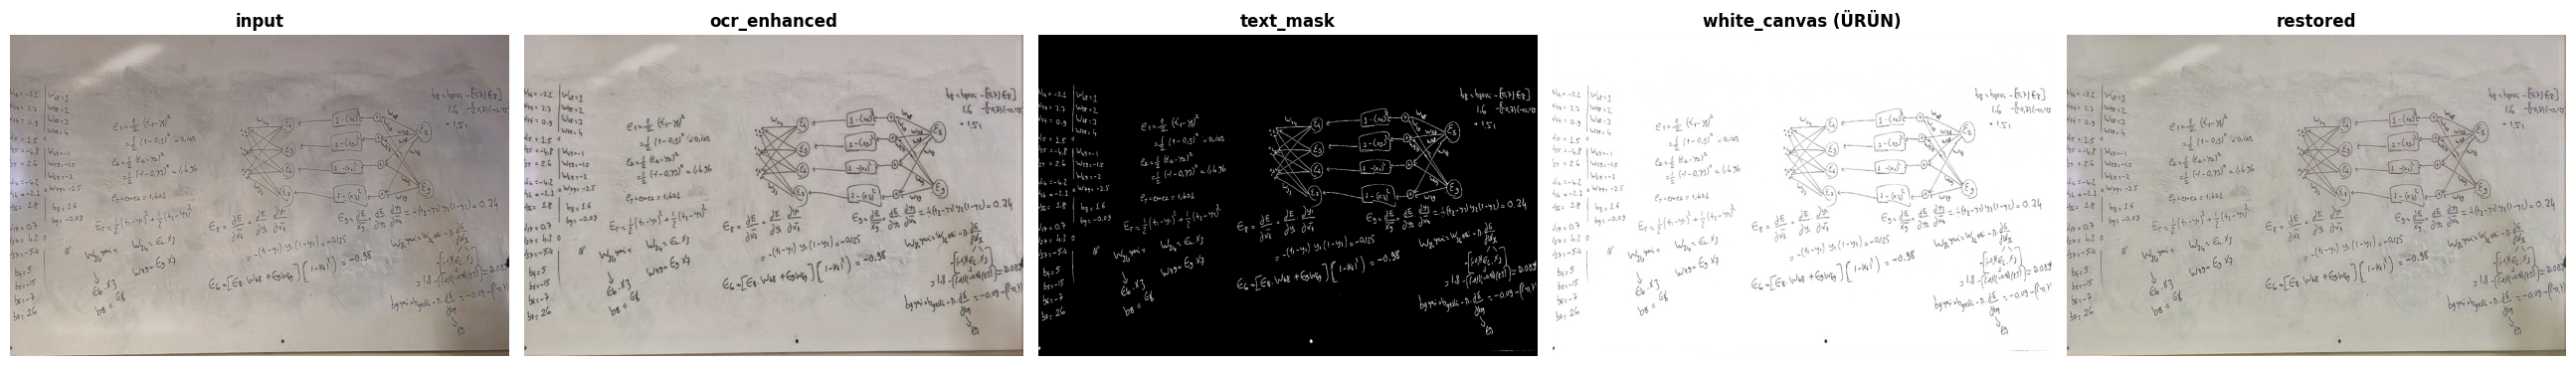

Kaydedildi: /content/runs_local/nafnet_multihead_v3_sup_gan/manual_inference/model2_input (2)_white_canvas.png


In [19]:
# ============================================================
# 15) Gerçek görüntü inference: ocr_enhanced + text_mask + white_canvas
# (backend pipeline ile aynı: white_canvas = ocr x text_mask)
# ============================================================
from google.colab import files

try:
    final_model
except NameError:
    final_model = build_model().to(DEVICE)
    ck = safe_load(CFG.LOCAL_RUN_DIR / CFG.EXP_NAME / "final_model.pt")
    final_model.load_state_dict(ck["model"], strict=True)
final_model.eval()

@torch.no_grad()
def infer_board(img_rgb01):
    """img_rgb01: HxWx3 [0,1] -> (restored, ocr, mask_prob, white_canvas)"""
    H, W = img_rgb01.shape[:2]
    t = torch.from_numpy(np.ascontiguousarray(img_rgb01)).permute(2,0,1).unsqueeze(0).float().to(DEVICE)
    with amp_ctx():
        o = final_model(t)
    rest = o["restored"].clamp(0,1)[0].float().cpu().numpy().transpose(1,2,0)
    ocr  = o["ocr"].clamp(0,1)[0].float().cpu().numpy().transpose(1,2,0)
    mp   = torch.sigmoid(o["mask_logits"])[0,0].float().cpu().numpy()
    canvas = make_white_canvas_np(o["ocr"].clamp(0,1)[0].cpu().numpy(), mp)
    return rest, ocr, mp, canvas

print("Tahta/board crop görseli yükle:")
uploaded = files.upload()
infer_dir = CFG.LOCAL_RUN_DIR / CFG.EXP_NAME / "manual_inference"; infer_dir.mkdir(parents=True, exist_ok=True)

for fname in uploaded.keys():
    path = Path("/content") / fname
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    assert bgr is not None, f"okunamadı: {path}"
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    rest, ocr, mp, canvas = infer_board(rgb)
    pred_mask = (mp > CFG.MASK_THRESHOLD).astype(np.float32)

    fig, ax = plt.subplots(1, 5, figsize=(26, 6))
    for a,(t,img,cm) in zip(ax, [("input",rgb,None),("ocr_enhanced",ocr,None),
                                  ("text_mask",mp,"gray"),("white_canvas (ÜRÜN)",canvas,None),
                                  ("restored",rest,None)]):
        a.imshow(img, cmap=cm); a.set_title(t, fontsize=12, fontweight="bold"); a.axis("off")
    plt.tight_layout(); plt.show()

    stem = Path(fname).stem
    Image.fromarray((np.clip(ocr,0,1)*255).astype(np.uint8)).save(infer_dir/f"{stem}_ocr.png")
    Image.fromarray((mp*255).astype(np.uint8)).save(infer_dir/f"{stem}_mask.png")
    Image.fromarray((np.clip(canvas,0,1)*255).astype(np.uint8)).save(infer_dir/f"{stem}_white_canvas.png")
    Image.fromarray((np.clip(rest,0,1)*255).astype(np.uint8)).save(infer_dir/f"{stem}_restored.png")
    print("Kaydedildi:", infer_dir/f"{stem}_white_canvas.png")